In [11]:
## 2026.06.13 using SeededNTM env
##            Copy from Xenium_lung/Data_process_visual_xenium_4.ipynb
##            See the HE image
## 2026.06.18 Clean code, and then add ‘Michael_data_transfer/s4769/HE/s4769_he_mapping_updated_Visium.xlsx’
##            - 21 available, actually 38 aligned HE images, save cell type at HE/nwn-95916_aligned_d1ec33a2/figures/
##            - FinalLiv-27_c001_v001_r001_reg005_celltype_on_HE.jpg
##            - nwn-95916_aligned_d1ec33a2.tif
## 2026.08.10 See the paper of CODEX-hcc https://www.biorxiv.org/content/10.1101/2025.06.11.656869v1.full
##            - 12 celltype based on the paper, see the cell type color
##            - not only 'Unknown' (before) and 'Stroma Uncharacterized' (this time), by adjust the celltype_filter parameter
## 


In [12]:
# cd /home/lingyu/ssd2/Python/Hist2Pheno
# bash code/Xenium_lung/demo_VUILD107MA.sh
# bash code/Xenium_lung/demo_VUILD102LA.sh
# bash code/Xenium_lung/demo_VUILD96LA.sh

In [25]:
## for AI edit
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
import os
os.chdir(f'{path}Hist2Pheno/data/CODEX/HCC/')
!pwd

import sys
import importlib
import pandas as pd
from pathlib import Path

_xenium_dir = Path("/home/lingyu/ssd2/Python/Hist2Pheno/code/Xenium_lung")
_codex_dir = Path("/home/lingyu/ssd2/Python/Hist2Pheno/code/CODEX_hcc")
for _d in (_xenium_dir, _codex_dir):
    if str(_d) not in sys.path:
        sys.path.insert(0, str(_d))

import s4769_img_cell_mapping
importlib.reload(s4769_img_cell_mapping)
from s4769_img_cell_mapping import (
    DEFAULT_CODEX_HCC_DIR,
    S4769_SAMPLE,
    load_visium_he_mapping,
    load_codex_he_alignment,
    load_codex_celltype_hierarchy,
    export_he_zarr_to_tif,
    export_aligned_he_zarrs_to_tif,
    export_aligned_codex_celltypes_to_jpg,
    summarize_visium_he_mapping,
    summarize_codex_he_alignment,
    load_he_rgb,
    plot_he_overview,
    load_cells_by_acq,
    load_cells_from_mapping,
    filter_alignment_with_annotation,
    summarize_celltype_distributions,
    celltype_count_table,
    summarize_acquisitions,
    plot_all_acq_spatial,
    plot_celltype_jpg,
    show_saved_jpg,
    preview_aligned_celltype_jpgs,
    plot_all_visium_on_he,
    load_visium_for_acq,
)

import importlib
import s4769_plot
importlib.reload(s4769_plot)
from s4769_plot import (
    Cell_Type_COLORS_CODEX_hcc_level2,
    load_hcc_celltypes,
    hcc_celltype_color_map,
    plot_celltype_proportions_stacked,
    plot_all_acq_celltype_distributions,
    plot_pooled_celltype_distribution,
)

HCC_CELLTYPES = load_hcc_celltypes()
HCC_CELLTYPE_COLORS = hcc_celltype_color_map()
print(f"HCC cell types retained: {len(HCC_CELLTYPES)}")
print(HCC_CELLTYPES)

CODEX_hcc_dir = str(DEFAULT_CODEX_HCC_DIR)
print("s4769_img_cell_mapping loaded from:", s4769_img_cell_mapping.__file__)


/nobackup2/users/lingyu/Python/Collaborate/esccAI/data
HCC cell types retained: 12
['Fibroblasts', 'CD8 T cells', 'Macrophages', 'INFg+', 'CD4 T cells', 'Endothelial cells', 'Epithelium (INOS+)', 'Neutrophils', 'Macrophages M2-like', 'B cells', 'Dendritic cells', 'Epithelium (INOS-)']
s4769_img_cell_mapping loaded from: /home/lingyu/ssd2/Python/Collaborate/esccAI/code/CODEX_hcc/s4769_img_cell_mapping.py


### Load HE

HE nwn-95916_aligned_d1ec33a2: shape=(3, 5431, 7236), dtype=uint8
HE RGB array: (5431, 7236, 3), value range [0, 255]
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/nwn-95916_aligned_d1ec33a2/figures/he_img_overview.jpg


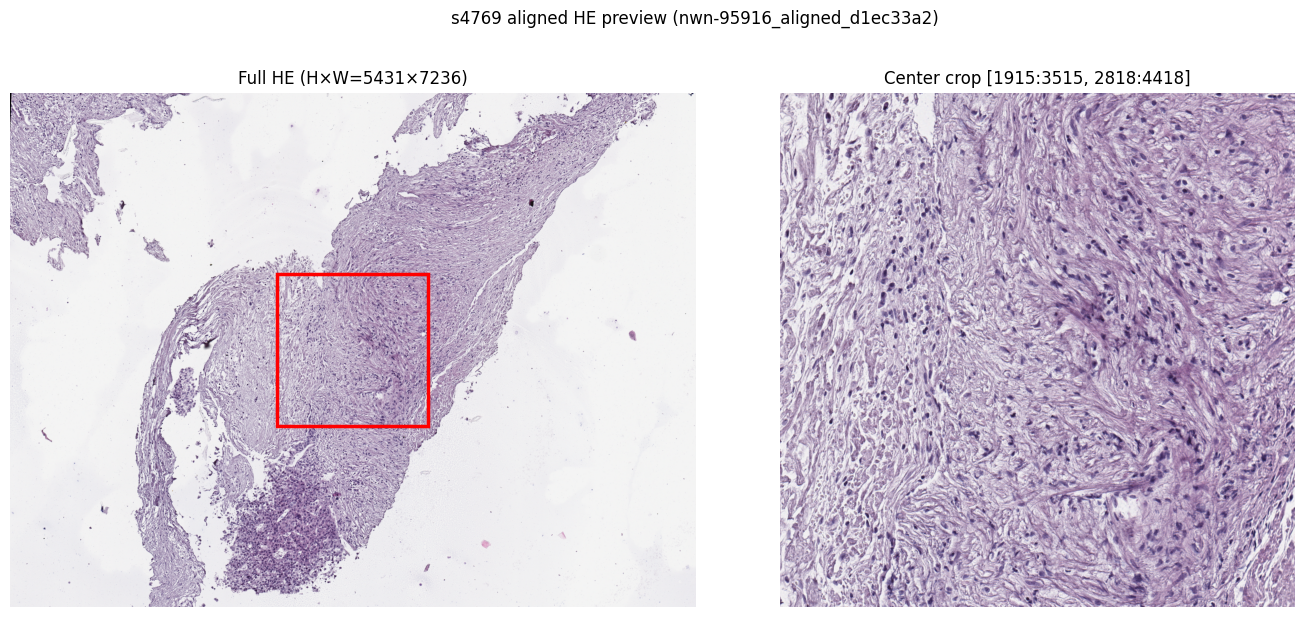

In [14]:
# reg005 aligned HE (reg006 uses nwn-95916_aligned_b16cf712)
HE_PREVIEW_KEYS = [
    'nwn-95916_aligned_d1ec33a2',   # reg005
    # 'nwn-95916_aligned_b16cf712',   # reg006
]

for he_key in HE_PREVIEW_KEYS:
    he_rgb, _ = plot_he_overview(he_key, base_dir=CODEX_hcc_dir)


### Load HE ↔ CODEX aligment (ALIGNED=Y only)
Load HE ↔ CODEX ↔ Visium mapping (Visium=Y only)


In [15]:
## Visium subset (21 rows): Visium=='Y' — required for Visium spot loading
# mapping_df = load_visium_he_mapping(base_dir=CODEX_hcc_dir)
# summarize_visium_he_mapping(mapping_df, base_dir=CODEX_hcc_dir)

## CODEX↔HE alignment (38 rows): ALIGNED=='Y' — use for CODEX cell overlay on HE
alignment_df = load_codex_he_alignment(base_dir=CODEX_hcc_dir)
summarize_codex_he_alignment(alignment_df, base_dir=CODEX_hcc_dir)

## Example: load CODEX cells for selected regions
PRIMARY_ACQ_ID = 'FinalLiv-27_c001_v001_r001_reg005'
ACQ_IDS_ALSO_VIEW = []  # e.g. ['FinalLiv-27_c001_v001_r001_reg006']

cells_by_acq = load_cells_by_acq(
    PRIMARY_ACQ_ID, ACQ_IDS_ALSO_VIEW or None, base_dir=CODEX_hcc_dir,
)
cells = cells_by_acq[PRIMARY_ACQ_ID]
summarize_acquisitions(cells_by_acq, alignment_df)

CODEX↔HE alignment rows: 38

=== FinalLiv-27_c001_v001_r001_reg001 | 70_2 ===
  MATCHED_HE='awy-98938_aligned_0d535a74'  exists=True
  Visium=False  CSV='070_2_tissue_positions_list.csv'  exists=False

=== FinalLiv-27_c001_v001_r001_reg002 | 70_3 ===
  MATCHED_HE='awy-98938_aligned_8ded610e'  exists=True
  Visium=False  CSV='070_3_tissue_positions_list.csv'  exists=False

=== FinalLiv-27_c001_v001_r001_reg003 | 70_4 ===
  MATCHED_HE='awy-98938_aligned_a5afeef9'  exists=True
  Visium=False  CSV='070_4_tissue_positions_list.csv'  exists=False

=== FinalLiv-27_c001_v001_r001_reg004 | 70_5 ===
  MATCHED_HE='awy-98938_aligned_59f27598'  exists=True
  Visium=False  CSV='070_5_tissue_positions_list.csv'  exists=False

=== FinalLiv-27_c001_v001_r001_reg005 | 71_2 ===
  MATCHED_HE='nwn-95916_aligned_d1ec33a2'  exists=True
  Visium=True  CSV='071_2_tissue_positions_list.csv'  exists=True

=== FinalLiv-27_c001_v001_r001_reg006 | 71_3 ===
  MATCHED_HE='nwn-95916_aligned_b16cf712'  exists=True
  Vi

### Export ALIGNED HE Zarr → TIFF (38 datasets)

In [ ]:
## Export ALIGNED HE Zarr → TIFF (38 datasets)
# Each HE saved as: s4769/HE/{MATCHED_HE}/figures/{MATCHED_HE}.tif


# he_tif_paths = export_aligned_he_zarrs_to_tif(
#     alignment_df,
#     base_dir=CODEX_hcc_dir,
#     skip_if_exists=True,   # set overwrite=True to re-export
# )
# print(f"Done: {len(he_tif_paths)} TIFF files")
# he_tif_paths[:3]

Exporting 38 HE Zarr → TIFF
SKIP (exists): /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/figures/awy-98938_aligned_0d535a74.tif


Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_8ded610e/figures/awy-98938_aligned_8ded610e.tif  shape=(5434, 7310, 3) dtype=uint8
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_a5afeef9/figures/awy-98938_aligned_a5afeef9.tif  shape=(5434, 7310, 3) dtype=uint8
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_59f27598/figures/awy-98938_aligned_59f27598.tif  shape=(5402, 7310, 3) dtype=uint8
SKIP (exists): /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/nwn-95916_aligned_d1ec33a2/figures/nwn-95916_aligned_d1ec33a2.tif
SKIP (exists): /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/nwn-95916_aligned_b16cf712/figures/nwn-95916_aligned_b16cf712.tif
SKIP (exists): /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s476

[PosixPath('/home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/figures/awy-98938_aligned_0d535a74.tif'),
 PosixPath('/home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_8ded610e/figures/awy-98938_aligned_8ded610e.tif'),
 PosixPath('/home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_a5afeef9/figures/awy-98938_aligned_a5afeef9.tif')]

In [10]:
# alignment_df
cells_by_acq

{'FinalLiv-27_c001_v001_r001_reg005':       CELL_ID  x_pix  y_pix  VALUE             celltype
 0           1   6624      4      3          Fibroblasts
 1           2    627      5     12              B cells
 2           3    130      4      7          CD4 T cells
 3           4    302      6      3          Fibroblasts
 4           5   1229      6      7          CD4 T cells
 ...       ...    ...    ...    ...                  ...
 8691     8692   1908   5383      3          Fibroblasts
 8692     8693   1810   5396      6  Macrophages M2-like
 8693     8694   2045   5415     11   Epithelium (INOS-)
 8694     8695   1759   5420      6  Macrophages M2-like
 8695     8696   1787   5421     13                INFg+
 
 [8696 rows x 5 columns]}

### CODEX cell types on MATCHED_HE → JPG (36 datasets)

In [ ]:
## CODEX cell types on MATCHED_HE → JPG (36 datasets)
# Saved as: s4769/HE/{MATCHED_HE}/figures/{CODEX_ACQUISITION_ID}_celltype_on_HE.jpg   [No]
# e.g. .../nwn-95916_aligned_d1ec33a2/figures/FinalLiv-27_c001_v001_r001_reg005_celltype_on_HE.jpg   [Yes]


# celltype_jpg_paths = export_aligned_codex_celltypes_to_jpg(
#     alignment_df,
#     base_dir=CODEX_hcc_dir,
#     skip_if_exists=True,   # set overwrite=True to re-export
#     show=False,
# )
# print(f"Done: {len(celltype_jpg_paths)} JPG files")
# celltype_jpg_paths[:3]


Exporting 38 CODEX cell-type maps → JPG
SKIP (exists): /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/figures/FinalLiv-27_c001_v001_r001_reg001_celltype_on_HE.jpg
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_8ded610e/figures/FinalLiv-27_c001_v001_r001_reg002_celltype_on_HE.jpg
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_a5afeef9/figures/FinalLiv-27_c001_v001_r001_reg003_celltype_on_HE.jpg
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_59f27598/figures/FinalLiv-27_c001_v001_r001_reg004_celltype_on_HE.jpg
SKIP (exists): /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/nwn-95916_aligned_d1ec33a2/figures/FinalLiv-27_c001_v001_r001_reg005_celltype_on_HE.jpg
SKIP (exists): /home/lingyu/ssd2/Python/Collabora

[PosixPath('/home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/figures/FinalLiv-27_c001_v001_r001_reg001_celltype_on_HE.jpg'),
 PosixPath('/home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_8ded610e/figures/FinalLiv-27_c001_v001_r001_reg002_celltype_on_HE.jpg'),
 PosixPath('/home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_a5afeef9/figures/FinalLiv-27_c001_v001_r001_reg003_celltype_on_HE.jpg')]

### Preview saved cell-type JPGs

In [17]:
## Preview saved cell-type JPGs
## plot_all_acq_spatial loops over cells_by_acq only — currently 1 region if ACQ_IDS_ALSO_VIEW=[]
# plot_all_acq_spatial(cells_by_acq, alignment_df, base_dir=CODEX_hcc_dir, show=True, reuse_existing=True)

# Preview ALL saved JPGs from alignment_df (38 regions; skips missing JPG)
# preview_aligned_celltype_jpgs(alignment_df, base_dir=CODEX_hcc_dir, show=True)

## Or preview selected regions only:
# preview_aligned_celltype_jpgs(
#     alignment_df, base_dir=CODEX_hcc_dir,
#     acq_ids=['FinalLiv-27_c001_v001_r001_reg005', 'FinalLiv-27_c001_v001_r001_reg006'],
# )

## Visualization

In [16]:
## CODEX↔HE alignment (38 rows): ALIGNED=='Y' — use for CODEX cell overlay on HE
alignment_df = load_codex_he_alignment(base_dir=CODEX_hcc_dir)
print('The number of CODEX↔HE alignment:', alignment_df.shape)

alignment_Anno_df = alignment_df[alignment_df['Annotation'].astype(str).str.upper() == 'Y'].copy()
print('The number of CODEX↔HE alignment with Annotation:', alignment_Anno_df.shape)
display(alignment_Anno_df.head())

## Hist2Pheno hierarchy: celltype_level2 → celltype_level1 → celltype_level0
celltype_hierarchy_df = load_codex_celltype_hierarchy(base_dir=CODEX_hcc_dir)
print('The number of retained hierarchy cell types:', len(celltype_hierarchy_df))
print(celltype_hierarchy_df.nunique().rename('n_classes').to_string())
display(celltype_hierarchy_df)

if set(HCC_CELLTYPES) != set(celltype_hierarchy_df['celltype_level2']):
    raise ValueError('HCC_CELLTYPES and celltype hierarchy Level2 labels do not match')

# summarize_codex_he_alignment(alignment_df, base_dir=CODEX_hcc_dir)

The number of CODEX↔HE alignment: (38, 19)
The number of CODEX↔HE alignment with Annotation: (36, 19)


,HE_ACQUISITION_ID,HE_REGION_DISPLAY_LABEL,MATCHED_HE,MATCHED_HE2,CODEX_ACQUISITION_ID,CODEX_REGION_DISPLAY_LABEL,ALIGNED,Visium,Annotation,acq_id,tissue_type,tissue_subtype,diagnosis,Response,species,treatment,Stain_Batch,patient_id,region_label
0,awy-98938,070_HE,awy-98938_aligned_0d535a74,NaN,FinalLiv-27_c001_v001_r001_reg001,70_2,Y,N,Y,FinalLiv-27_c001_v001_r001_reg001,Liver,Primary,Pre,Responder,Human,List A,10 13_14 2022,85557,70_2
1,awy-98938,070_HE,awy-98938_aligned_8ded610e,NaN,FinalLiv-27_c001_v001_r001_reg002,70_3,Y,N,Y,FinalLiv-27_c001_v001_r001_reg002,Liver,Primary,Pre,Responder,Human,List A,10 13_14 2022,85557,70_3
2,awy-98938,070_HE,awy-98938_aligned_a5afeef9,NaN,FinalLiv-27_c001_v001_r001_reg003,70_4,Y,N,Y,FinalLiv-27_c001_v001_r001_reg003,Liver,Primary,Post,Responder,Human,List A,10 13_14 2022,85557,70_4
3,awy-98938,070_HE,awy-98938_aligned_59f27598,NaN,FinalLiv-27_c001_v001_r001_reg004,70_5,Y,N,Y,FinalLiv-27_c001_v001_r001_reg004,Liver,Primary,Post,Responder,Human,List A,10 13_14 2022,85557,70_5
4,nwn-95916,071_HE,nwn-95916_aligned_d1ec33a2,NaN,FinalLiv-27_c001_v001_r001_reg005,71_2,Y,Y,Y,FinalLiv-27_c001_v001_r001_reg005,Liver,Primary,Pre,Responder,Human,List A,10 13_14 2022,85558,71_2


The number of retained hierarchy cell types: 12
celltype_level2    12
celltype_level1     6
celltype_level0     4


,celltype_level2,celltype_level1,celltype_level0
0,Fibroblasts,Stromal,Stromal
1,CD8 T cells,T cells,Immune
2,Macrophages,Myeloid,Immune
3,INFg+,T cells,Immune
4,CD4 T cells,T cells,Immune
5,Endothelial cells,Endothelial,Endothelial
6,Epithelium (INOS+),Epithelial,Epithelial
7,Neutrophils,Myeloid,Immune
8,Macrophages M2-like,Myeloid,Immune
9,B cells,B cells,Immune


In [17]:
## Load all 36 annotated CODEX datasets + cell-type distribution
alignment_Anno_df = filter_alignment_with_annotation(alignment_df)
print(f"CODEX↔HE with annotation: {len(alignment_Anno_df)} datasets")
summarize_codex_he_alignment(alignment_Anno_df, base_dir=CODEX_hcc_dir)

cells_by_acq = load_cells_from_mapping(
    alignment_Anno_df,
    base_dir=CODEX_hcc_dir,
    skip_missing_annotation=True,
)


CODEX↔HE with annotation: 36 datasets
CODEX↔HE alignment rows: 36

=== FinalLiv-27_c001_v001_r001_reg001 | 70_2 ===
  MATCHED_HE='awy-98938_aligned_0d535a74'  exists=True
  Visium=False  CSV='070_2_tissue_positions_list.csv'  exists=False

=== FinalLiv-27_c001_v001_r001_reg002 | 70_3 ===
  MATCHED_HE='awy-98938_aligned_8ded610e'  exists=True
  Visium=False  CSV='070_3_tissue_positions_list.csv'  exists=False

=== FinalLiv-27_c001_v001_r001_reg003 | 70_4 ===
  MATCHED_HE='awy-98938_aligned_a5afeef9'  exists=True
  Visium=False  CSV='070_4_tissue_positions_list.csv'  exists=False

=== FinalLiv-27_c001_v001_r001_reg004 | 70_5 ===
  MATCHED_HE='awy-98938_aligned_59f27598'  exists=True
  Visium=False  CSV='070_5_tissue_positions_list.csv'  exists=False

=== FinalLiv-27_c001_v001_r001_reg005 | 71_2 ===
  MATCHED_HE='nwn-95916_aligned_d1ec33a2'  exists=True
  Visium=True  CSV='071_2_tissue_positions_list.csv'  exists=True

=== FinalLiv-27_c001_v001_r001_reg006 | 71_3 ===
  MATCHED_HE='nwn-959

In [9]:
celltype_counts = summarize_celltype_distributions(cells_by_acq, alignment_Anno_df, celltype_filter=['Unknown', 'Stroma Uncharacterized'])
print('celltype_counts.shape:', celltype_counts.shape)
celltype_counts


=== FinalLiv-27_c001_v001_r001_reg001 (region 70_2) — 33060 retained cells ===
celltype
Fibroblasts            7387
CD8 T cells            6176
Macrophages            4636
INFg+                  4183
CD4 T cells            3098
Endothelial cells      2190
Epithelium (INOS+)     1788
Neutrophils            1354
Macrophages M2-like    1074
B cells                 474
Dendritic cells         429
Epithelium (INOS-)      271

=== FinalLiv-27_c001_v001_r001_reg002 (region 70_3) — 12291 retained cells ===
celltype
Epithelium (INOS+)     4642
Macrophages            1691
CD4 T cells            1676
Endothelial cells      1411
CD8 T cells             728
Macrophages M2-like     604
Dendritic cells         454
B cells                 423
Fibroblasts             340
INFg+                   154
Epithelium (INOS-)      124
Neutrophils              44

=== FinalLiv-27_c001_v001_r001_reg003 (region 70_4) — 42524 retained cells ===
celltype
CD4 T cells            8756
Macrophages            7984
CD8 T

,FinalLiv-27_c001_v001_r001_reg001,FinalLiv-27_c001_v001_r001_reg002,FinalLiv-27_c001_v001_r001_reg003,FinalLiv-27_c001_v001_r001_reg004,FinalLiv-27_c001_v001_r001_reg005,FinalLiv-27_c001_v001_r001_reg006,FinalLiv-27_c001_v001_r001_reg007,FinalLiv-27_c001_v001_r001_reg008,FinalLiv-27_c001_v001_r001_reg009,FinalLiv-27_c001_v001_r001_reg010,...,FinalLiv-27_c002_v001_r001_reg009,FinalLiv-27_c002_v001_r001_reg010,FinalLiv-27_c002_v001_r001_reg011,FinalLiv-27_c002_v001_r001_reg012,FinalLiv-27_c002_v001_r001_reg013,FinalLiv-27_c002_v001_r001_reg014,FinalLiv-27_c002_v001_r001_reg015,FinalLiv-27_c002_v001_r001_reg016,FinalLiv-27_c002_v001_r001_reg017,FinalLiv-27_c002_v001_r001_reg018
celltype,,,,,,,,,,,,,,,,,,,,,
Fibroblasts,7387,340,6951,6855,2172,4186,8473,9821,418,125,...,1042,4176,1668,1850,630,411,1311,1185,1185,701
CD8 T cells,6176,728,7700,4945,779,2290,4411,4695,2603,1028,...,204,9477,7060,1184,1697,1452,1487,1758,1896,1431
Macrophages,4636,1691,7984,7535,1278,2542,6836,8721,2607,2541,...,1331,4897,4137,3513,5289,6233,3084,4082,3083,1324
INFg+,4183,154,4424,1752,576,546,364,428,71,37,...,74,4457,1622,1120,134,293,881,376,335,120
CD4 T cells,3098,1676,8756,4552,892,1973,5046,3564,162,78,...,332,4869,2432,3134,3082,3337,2237,2648,2437,1819
Endothelial cells,2190,1411,1208,706,413,980,3028,3700,776,450,...,853,2571,1707,2735,5009,4476,1884,2605,4411,2190
Epithelium (INOS+),1788,4642,0,0,1100,1822,4830,7786,7298,7261,...,4199,7868,19697,8090,3466,3750,3983,4840,17404,10587
Neutrophils,1354,44,413,511,133,982,3558,5835,872,554,...,467,1016,377,2805,2252,3916,567,1937,768,620
Macrophages M2-like,1074,604,1757,1574,554,1401,4631,5492,873,974,...,723,2459,2000,1568,2980,3212,853,552,2857,1551


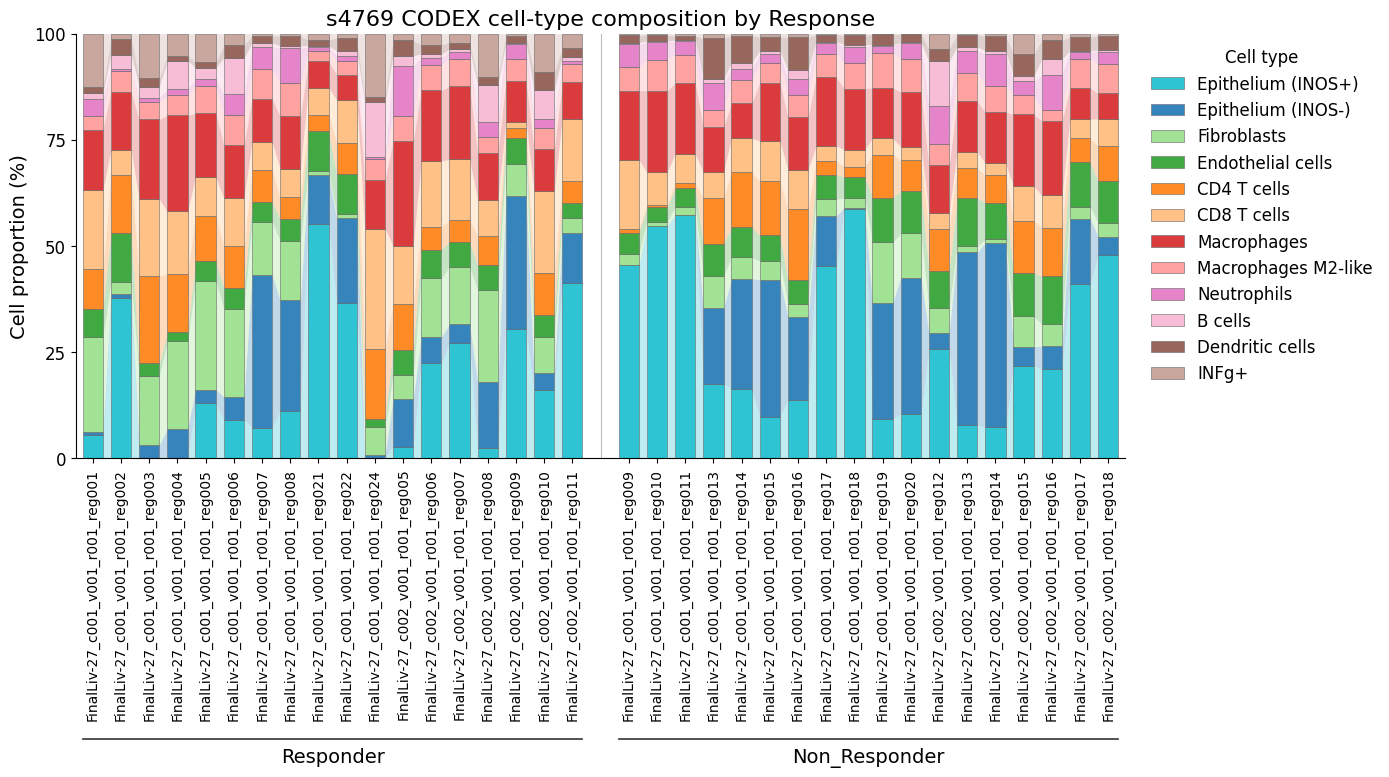

In [28]:
figure_save_path = Path(CODEX_hcc_dir) / "Results" / "figures"

## 2026.08.10 — 100% stacked cell-type composition across acquisitions
plot_celltype_proportions_stacked(
    celltype_counts,
    rotation=90,
    xtick_fontsize=10,
    ytick_fontsize=12,
    label_fontsize=14,
    title_fontsize=16,
    legend_fontsize=12,
    legend_title_fontsize=12,
    celltype_order=list(Cell_Type_COLORS_CODEX_hcc_level2),
    condition_df=alignment_Anno_df,
    condition="Response",
    condition_order=["Responder", "Non_Responder"],
    condition_gap=1.0,
    condition_line_y=-0.66,
    condition_label_y=-0.68,
    bottom_margin=0.42,
    figsize=(14, 8),
    title="s4769 CODEX cell-type composition by Response",
    xlabel="",
    show_shading=True,
    shading_alpha=0.28,
    bar_width=0.72,
    bar_alpha=0.90,
    save_path=None,
    # save_path=figure_save_path / "s4769_celltype_proportions_stacked.pdf",
)

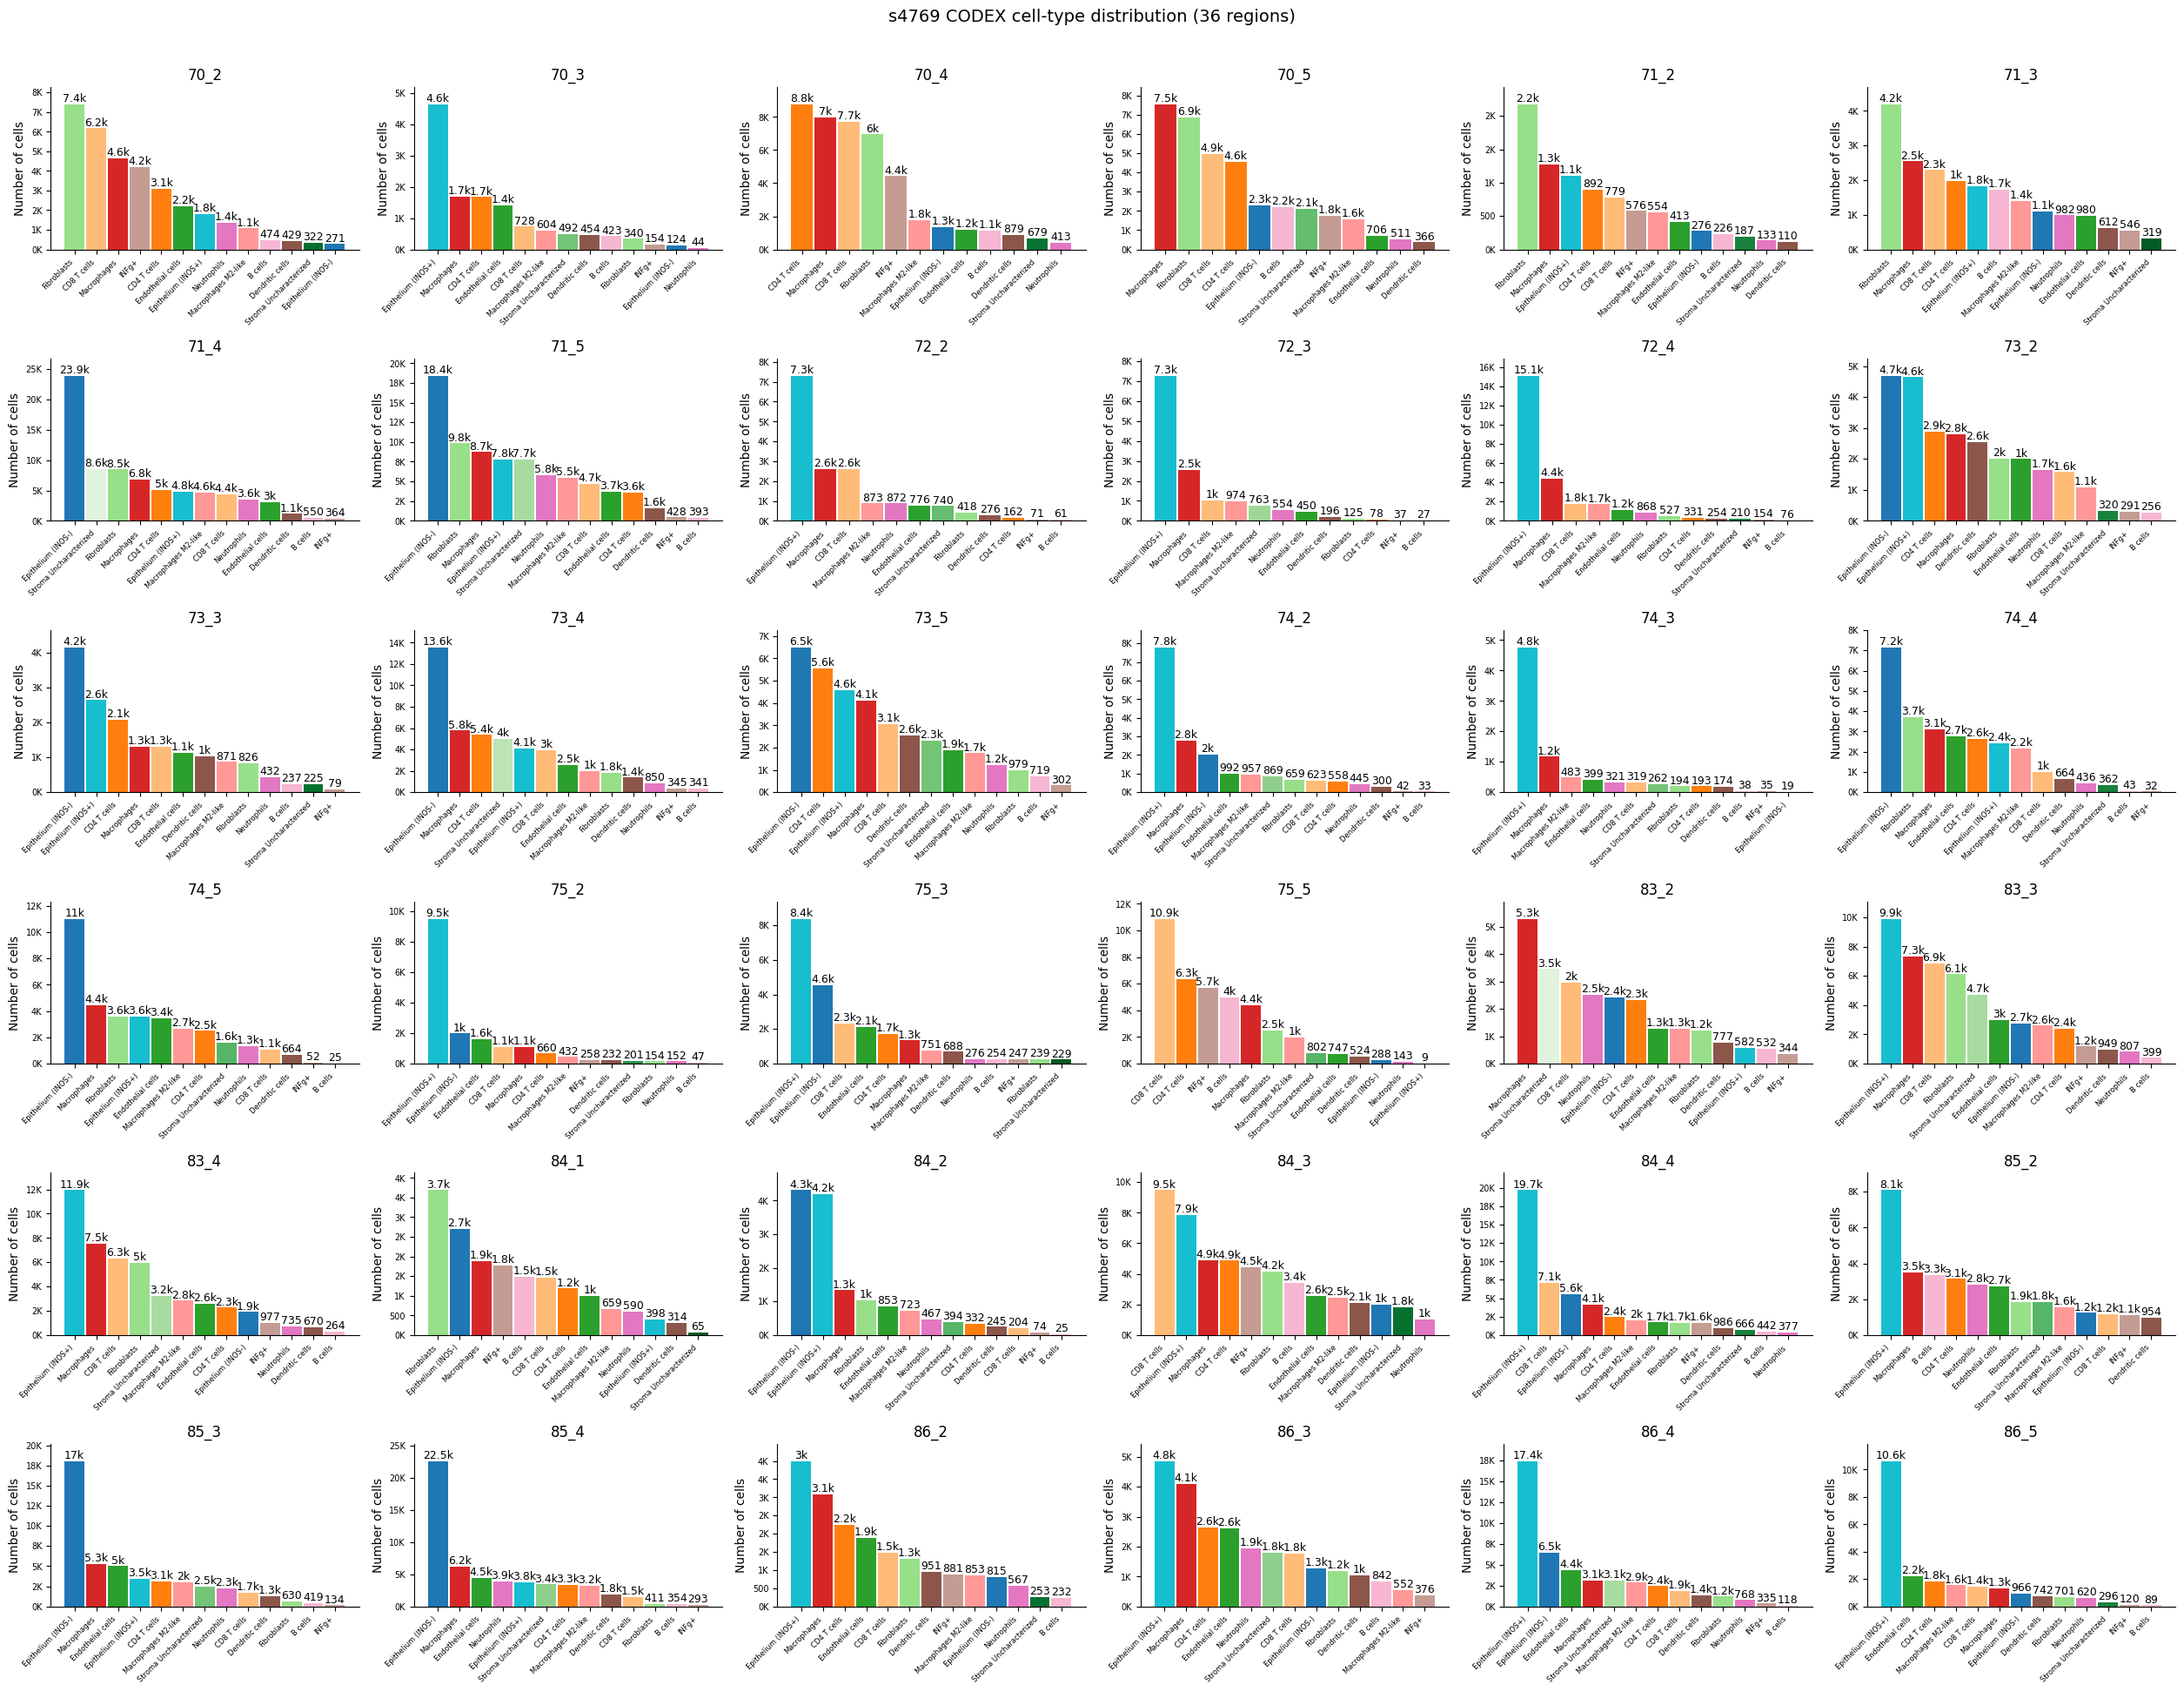

In [10]:
# 36 regions: one bar chart per dataset (6 x 6 grid)
plot_all_acq_celltype_distributions(
    cells_by_acq,
    alignment_Anno_df,
    n_cols=6,
    exclude_unknown=True,
    save_path=None,
    # save_path=figure_save_path / "s4769_36regions_celltype_distribution.pdf",
)

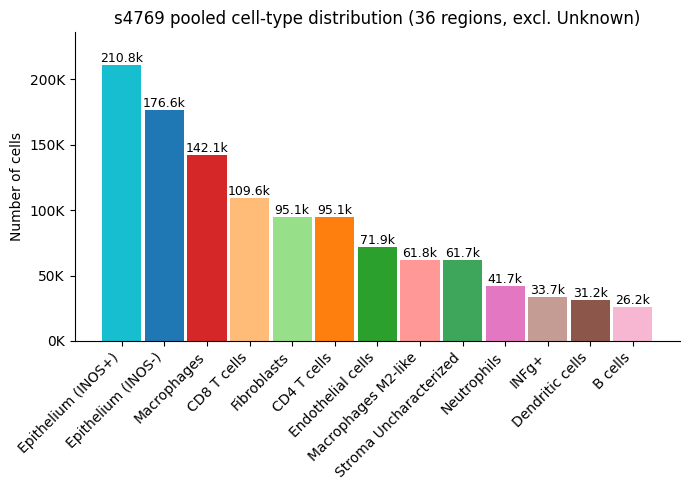

In [11]:
# Optional: pooled distribution across all 36 regions
plot_pooled_celltype_distribution(
    cells_by_acq,
    exclude_unknown=True,
    figsize=(7, 5),
    save_path=None,
    # save_path=figure_save_path / "s4769_pooled_celltype_distribution.pdf",
)